In [10]:
import math
import pandas as pd
import joblib
from pathlib import Path
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [11]:
# Dois clientes escalas completamente diferentes
p1 = {"salary": 5000, "historico": 9} # Bom pagador
p2 = {"salary": 5001, "historico": 1} # Pessimo pagador

dx = p1["salary"] - p2["salary"]
dy = p1["historico"] - p2["historico"]
dist = math.sqrt(dx**2 + dy**2)

print(f"Distancia sem normaliação: {dist:.2f}")

Distancia sem normaliação: 8.06


In [12]:
# Knn StandardScaler

df = pd.DataFrame([
    {"salary": 4000, "historico": 8, "aprovado": 1},
    {"salary": 1000, "historico": 2, "aprovado": 0},
    {"salary": 6000, "historico": 9, "aprovado": 1},
    {"salary": 2000, "historico": 3, "aprovado": 0},
    {"salary": 5000, "historico": 7, "aprovado": 1},
    {"salary": 1500, "historico": 1, "aprovado": 0},
    {"salary": 7000, "historico": 2, "aprovado": 1},
    {"salary": 3000, "historico": 1, "aprovado": 0},
    {"salary": 2000, "historico": 8, "aprovado": 1},
    {"salary": 5000, "historico": 5, "aprovado": 0},
    {"salary": 6000, "historico": 9, "aprovado": 1},
    {"salary": 7000, "historico": 4, "aprovado": 0},
    {"salary": 2000, "historico": 3, "aprovado": 1},
    {"salary": 3500, "historico": 2, "aprovado": 0},
    {"salary": 7000, "historico": 3, "aprovado": 1},
    {"salary": 2000, "historico": 5, "aprovado": 0},
])

X = df[["salary", "historico"]]
y = df["aprovado"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Para comparação
X_scaled_df = pd.DataFrame(X_scaled, columns=["salary", "historico"])
X_scaled_df["aprovado"] = y.values

# Treina o KNN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X_scaled, y)

print(f"Modelo Treinado com dados Normalizados")
print(X_scaled_df.round(2))

Modelo Treinado com dados Normalizados
    salary  historico  aprovado
0     0.00       1.27         1
1    -1.44      -0.91         0
2     0.96       1.63         1
3    -0.96      -0.54         0
4     0.48       0.91         1
5    -1.20      -1.27         0
6     1.44      -0.91         1
7    -0.48      -1.27         0
8    -0.96       1.27         1
9     0.48       0.18         0
10    0.96       1.63         1
11    1.44      -0.18         0
12   -0.96      -0.54         1
13   -0.24      -0.91         0
14    1.44      -0.54         1
15   -0.96       0.18         0


In [13]:
# Testando dois novos clientes
novos = pd.DataFrame([
    {"salary": 5000, "historico": 9},
    {"salary": 5001, "historico": 1}
])

novo_scaled = scaler.transform(novos)
previsoes = modelo.predict(novo_scaled)

for i, prev in enumerate(previsoes):
    label = "Aprovado" if prev == 1 else "Reprovado"
    print(f"Cliente {i+1} : {label}")

Cliente 1 : Aprovado
Cliente 2 : Reprovado


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_cls = df[["salary", "historico"]]
y_cls = df["aprovado"]

#stratify = mantém a proporção das classes aprovado e reprovado
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

print("Retorno do train_test_split:")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print()

# Escala com dados de treino e aplica no teste
scaler_cls = StandardScaler()
X_train_s = scaler_cls.fit_transform(X_train)
X_test_s = scaler_cls.transform(X_test)

# Treina e avalia
modelo_cls = KNeighborsClassifier(n_neighbors=3)
modelo_cls.fit(X_train_s, y_train)
y_pred = modelo_cls.predict(X_test_s)

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Reprovado", "Aprovado"],
    zero_division=0,
))

Retorno do train_test_split:
X_train: (12, 2) | X_test: (4, 2)
y_train: (12,) | y_test: (4,)

              precision    recall  f1-score   support

   Reprovado       0.67      1.00      0.80         2
    Aprovado       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



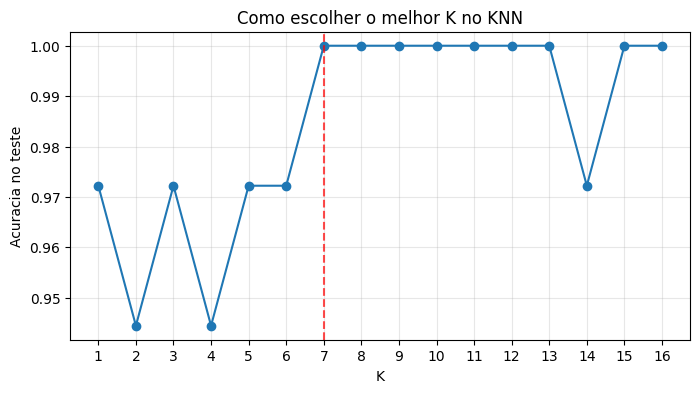

Melhor k sugerido pelo gráfico: 7


In [15]:
import matplotlib.pyplot as plt

# Wine: 178 amostras, 13 features, 3 classes
wine = load_wine()

df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine["classe"] = wine.target

X_wine = df_wine[wine.feature_names]
y_wine = df_wine["classe"]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Normalização
scaler_wine = StandardScaler()
X_train_w_s = scaler_wine.fit_transform(X_train_w)
X_test_w_s = scaler_wine.transform(X_test_w)

# Gráfico simples para escolher o K
k_values = range(1, 17)
acuracias = []

for k in k_values:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_w_s, y_train_w)
    acuracias.append(modelo_k.score(X_test_w_s, y_test_w))

melhor_k = k_values[acuracias.index(max(acuracias))]

plt.figure(figsize=(8,4))
plt.plot(list(k_values), acuracias, marker="o")
plt.xticks(list(k_values))
plt.xlabel("K")
plt.ylabel("Acuracia no teste")
plt.title("Como escolher o melhor K no KNN")
plt.grid(True, alpha=0.3)
plt.axvline(melhor_k, color="red", linestyle="--", alpha=0.7)
plt.show()

print(f"Melhor k sugerido pelo gráfico: {melhor_k}")



In [16]:
wine = load_wine()

vinhos = pd.DataFrame(wine.data, columns=wine.feature_names)

vinhos["tipo"] = [wine.target_names[t] for t in wine.target]
vinhos["id_vinho"] = vinhos.index

print("Amostra do catalogo:")
print(vinhos[["id_vinho", "tipo", "alcohol", "malic_acid", "color_intensity"]].head(8))

Amostra do catalogo:
   id_vinho     tipo  alcohol  malic_acid  color_intensity
0         0  class_0    14.23        1.71             5.64
1         1  class_0    13.20        1.78             4.38
2         2  class_0    13.16        2.36             5.68
3         3  class_0    14.37        1.95             7.80
4         4  class_0    13.24        2.59             4.32
5         5  class_0    14.20        1.76             6.75
6         6  class_0    14.39        1.87             5.25
7         7  class_0    14.06        2.15             5.05


In [17]:
X_rec = vinhos[wine.feature_names]

# Normalizar
scaler_rec = StandardScaler()
X_rec_scaled = scaler_rec.fit_transform(X_rec)

# euclidean ou manhattan
metrica_rec = "euclidean"

modelo_rec = NearestNeighbors(n_neighbors=4, metric=metrica_rec)
modelo_rec.fit(X_rec_scaled)

id_referencia = 10
referencia = X_rec_scaled[[id_referencia]]
distancias, indices = modelo_rec.kneighbors(referencia)

print(f"Metrica usada: {metrica_rec}")
print(f"Vinho de referencia (id={id_referencia}, tipo={vinhos.iloc[id_referencia]['tipo']})")
print()

print("Vinhos mais pareciso (incluindo ele mesmo na posição 0):")
for i, idx in enumerate(indices[0]):
    tipo = vinhos.iloc[idx]["tipo"]
    dist = distancias[0][i]
    print(f" id={idx} | tipo={tipo} | distancia={dist:.3f}")


Metrica usada: euclidean
Vinho de referencia (id=10, tipo=class_0)

Vinhos mais pareciso (incluindo ele mesmo na posição 0):
 id=10 | tipo=class_0 | distancia=0.000
 id=31 | tipo=class_0 | distancia=1.513
 id=51 | tipo=class_0 | distancia=1.910
 id=49 | tipo=class_0 | distancia=2.022


In [18]:
def recomendar_vinhos(id_vinho, n=3):
    referencia = X_rec_scaled[[id_vinho]]

    distancias, indices = modelo_rec.kneighbors(referencia, n_neighbors= n + 1)

    tipo_ref = vinhos.iloc[id_vinho]["tipo"]
    print(f"Quem gostou do vinho id={id_vinho} (tipo={tipo_ref}) pode gostar de :")
    for i, idx in enumerate(indices[0]):
        if idx == id_vinho:
            continue # Pula o proprio vinho de referencia
        tipo = vinhos.iloc[idx]["tipo"]
        dist = distancias[0][i]
        print(f" - id={idx} | tipo={tipo} | distancia={dist:.3f}")

    
recomendar_vinhos(10)
print()
recomendar_vinhos(130)

Quem gostou do vinho id=10 (tipo=class_0) pode gostar de :
 - id=31 | tipo=class_0 | distancia=1.513
 - id=51 | tipo=class_0 | distancia=1.910
 - id=49 | tipo=class_0 | distancia=2.022

Quem gostou do vinho id=130 (tipo=class_2) pode gostar de :
 - id=131 | tipo=class_2 | distancia=2.209
 - id=133 | tipo=class_2 | distancia=2.593
 - id=70 | tipo=class_1 | distancia=2.784
